In [1]:
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

# In[2]:  -------------------- User knobs (edit these) --------------------
casa = True
test = False
mode =  "validation"#"minimal_rho"
era = "2016"            # "2016", "2016APV", "2017", "2018", "all"
data = True     # True => data, False => MC
dataset = "pythia2"      # for MC: "pythia", "herwig", "st", "powheg", "backgrounds"
pre = 'reorder_validation_data_'
systematics_list = None#['nominal']
jet_systematics_list = None#['nominal']

systematics_list = ['nominal']
jet_systematics_list = ['nominal']
chunksize = 400000
chunksize_test = 100000

group_mode = "per_group"  #"all_in_one" # "per_group" (run list-of-lists separately) or "all_in_one" (flatten and run once)

prependstr = "root://xcache/"  # can swap to "root://cmsxrootd.fnal.gov/" etc.

In [2]:
import os
import time
import pickle
import importlib
from pathlib import Path

import numpy as np
import awkward as ak
import uproot

import coffea
from coffea.nanoevents import NanoAODSchema
from coffea import processor

# local package imports
import sys
sys.path.insert(0, os.path.abspath("/work"))
sys.path.insert(0, str(Path.cwd().parent / "src"))
import zjet_corrections
import zjet_corrections.zjet_processor
NanoAODSchema.warn_missing_crossrefs = False
importlib.reload(zjet_corrections.zjet_processor)
from zjet_corrections.zjet_processor_muon import ZplusJetProcessor

In [3]:
from pathlib import Path

def fileset_from_txt_list(txt_files, max_files=None):
    """
    txt_files : list of paths to txt files
    Each txt file corresponds to one dataset.
    Dataset name is inferred from txt filename.
    """

    fileset = {}
    prependstr = "root://xcache/"

    for txt_path in txt_files:
        txt_path = Path(txt_path)

        # Infer dataset name from txt filename
        name = txt_path.stem  # removes .txt

        # Clean naming logic
        if "SingleMuon" in name:
            dataset_name = "SingleMuon_UL2016"
        elif "pythia" in name.lower():
            dataset_name = "pythia"
        else:
            dataset_name = "pythia_UL16NanoAODv9"  # fallback: use filename directly

        files = []
        for line in txt_path.read_text().splitlines():
            line = line.strip()
            if (not line) or line.startswith("#"):
                continue
            files.append(prependstr + line)

        if max_files is not None:
            files = files[:max_files]

        fileset[dataset_name] = files

    return fileset

In [4]:
def ensure_client(casa: bool, test: bool, memory = "8 GiB"):
    """Create a Dask client only when needed."""
    if test:
        print("Running locally with 1-2 files (test=True)")
        return None

    from dask.distributed import Client
    if casa:
        from coffea_casa import CoffeaCasaCluster
        cluster = CoffeaCasaCluster(memory=memory)
        cluster.adapt(minimum=0, maximum=150)
        client = Client(cluster)
        print("✅ Dask client created (CoffeaCasaCluster).")
        return client

    # If you want a non-casa distributed client, put it here.
    print("ℹ️ casa=False: running without distributed client.")
    return None

def upload_package_if_casa(client, casa: bool):
    """Optional: zip + upload local package to workers."""
    if not casa or client is None:
        return

    import shutil
    import pathlib

    pkg_dir = pathlib.Path("/home/cms-jovyan/new_git/zjet_corrections/src/zjet_corrections")
    zip_path = pathlib.Path("/tmp/zjet_corrections.zip")
    if zip_path.exists():
        zip_path.unlink()

    shutil.make_archive(zip_path.with_suffix(""), "zip", pkg_dir.parent, pkg_dir.name)
    client.upload_file(str(zip_path))
    print("📦 Uploaded zjet_corrections.zip to workers.")

In [5]:
if test:
    max_files = 5
else:
    max_files = None
txt_path = ["samples_mc/inclusiveLO_UL16NanoAODv9.txt", "samples/SingleMuon_UL2016.txt"]   # <-- change
fileset = fileset_from_txt_list(txt_path, max_files = max_files)

In [6]:
if test:
    from coffea import processor
    from coffea.nanoevents import NanoAODSchema
    
    
    
    #iterative_executor runs locally, file-by-file — ideal for notebooks/debugging
    run = processor.Runner(
        executor=processor.FuturesExecutor(),
        schema=NanoAODSchema,
        chunksize=100_000,   # events per chunk
        maxchunks=6,      # set e.g. maxchunks=2 to test on a subset
    )
    
    out = run(
        fileset,
        "Events",
        processor_instance=ZplusJetProcessor(
                do_gen=not data,
                debug=False,
                systematics=['nominal'],
                jet_systematics=['nominal'],
                mode=mode
            ),
    )
    
    print("Cutflow:", dict(out["cutflow"]))
    

    


In [7]:
if not test:
    client = ensure_client(casa=casa, test=test, memory = "4 GiB")
    upload_package_if_casa(client, casa=casa)

{'memory': '4 GiB', 'protocol': 'tls://', 'security': Security(require_encryption=True, tls_ca_file=Local (/etc/cmsaf-secrets/ca.pem), tls_client_cert=Local (/etc/cmsaf-secrets/hostcert.pem), tls_client_key=Local (/etc/cmsaf-secrets/hostcert.pem), tls_min_version=771, tls_scheduler_cert=Local (/etc/cmsaf-secrets/hostcert.pem), tls_scheduler_key=Local (/etc/cmsaf-secrets/hostcert.pem), tls_worker_cert=Local (/etc/cmsaf-secrets/hostcert.pem), tls_worker_key=Local (/etc/cmsaf-secrets/hostcert.pem)), 'log_directory': 'logs', 'silence_logs': 'DEBUG', 'scheduler_options': {'port': 8786, 'dashboard_address': '8787', 'protocol': 'tls', 'contact_address': 'tls://aritra-2emandal-40cern-2ech.dask.cmsaf-prod.flatiron.hollandhpc.org:8786'}, 'job_extra_directives': {'universe': 'docker', 'docker_image': 'hub.opensciencegrid.org/coffea-casa/cc-analysis-alma9:2025.05.24', 'container_service_names': 'dask,nanny', 'dask_container_port': 8786, 'nanny_container_port': 8001, 'use_x509userproxy': False, 'tr

2026-03-04 22:40:28,317 - distributed.scheduler - INFO - State start
2026-03-04 22:40:28,323 - distributed.scheduler - INFO -   Scheduler at: tls://192.168.197.192:8786
2026-03-04 22:40:28,324 - distributed.scheduler - INFO -   dashboard at:  /user/aritra.mandal@cern.ch/proxy/8787/status
2026-03-04 22:40:28,325 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-03-04 22:40:28,334 - distributed.deploy.adaptive - INFO - Adaptive scaling started: minimum=0 maximum=150
2026-03-04 22:40:28,343 - distributed.scheduler - INFO - Receive client connection: Client-24a7aacb-181b-11f1-9ed9-06eeb246313a
2026-03-04 22:40:28,344 - distributed.core - INFO - Starting established connection to tls://192.168.197.192:39190


✅ Dask client created (CoffeaCasaCluster).


2026-03-04 22:40:32,361 - distributed.utils - INFO - Reload module zjet_corrections from .zip file
2026-03-04 22:40:32,388 - distributed.scheduler - INFO - Registering Worker plugin /tmp/zjet_corrections.zip45a2b1ec-a41e-4ac3-b202-effb7a65cb22


📦 Uploaded zjet_corrections.zip to workers.


2026-03-04 22:41:03,901 - distributed.scheduler - INFO - Register worker addr: tls://129.93.182.107:35579 name: htcondor--25563594.0--
2026-03-04 22:41:03,913 - distributed.scheduler - INFO - Starting worker compute stream, tls://129.93.182.107:35579
2026-03-04 22:41:03,914 - distributed.core - INFO - Starting established connection to tls://192.168.86.10:59838
2026-03-04 22:41:04,084 - distributed.scheduler - INFO - Register worker addr: tls://129.93.182.107:40637 name: htcondor--25563593.0--
2026-03-04 22:41:04,093 - distributed.scheduler - INFO - Starting worker compute stream, tls://129.93.182.107:40637
2026-03-04 22:41:04,093 - distributed.core - INFO - Starting established connection to tls://192.168.86.10:59848
2026-03-04 22:41:04,256 - distributed.scheduler - INFO - Register worker addr: tls://129.93.182.107:35589 name: htcondor--25563597.0--
2026-03-04 22:41:04,264 - distributed.scheduler - INFO - Starting worker compute stream, tls://129.93.182.107:35589
2026-03-04 22:41:04,2

In [8]:
if not test:
    run = processor.Runner(
        executor=processor.DaskExecutor(client=client),
        schema=NanoAODSchema,
        chunksize=400_000,
        maxchunks=None,     # set e.g. maxchunks=5 to test first
        skipbadfiles = True
    )
    
    out = run(
        fileset,
        "Events",
        processor_instance=ZplusJetProcessor(
                do_gen=not data,
                debug=False,
                systematics=['nominal'],
                jet_systematics=['nominal'],
                mode=mode
        ),
    )
    client.close()

[########################################] | 100% Completed |  4min 10.7s

/tmp/ipykernel_7897/3783678103.py:20: RuntimeWarning: divide by zero encountered in divide
  hep.histplot(vals0/vals1, out['pt_mu0'][:, hist.rebin(1), :].axes[1].edges)
/tmp/ipykernel_7897/3783678103.py:20: RuntimeWarning: invalid value encountered in divide
  hep.histplot(vals0/vals1, out['pt_mu0'][:, hist.rebin(1), :].axes[1].edges)


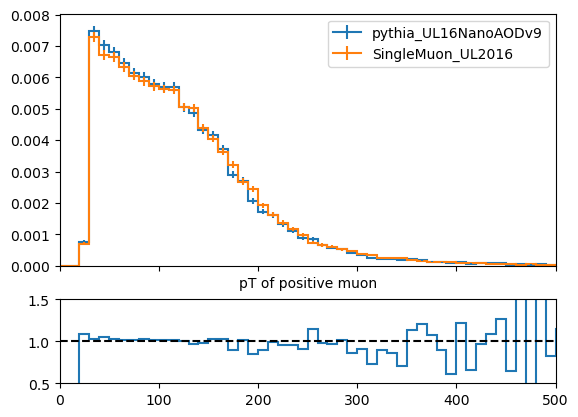

In [14]:
from coffea.hist import plot1d
import matplotlib.pyplot as plt
import mplhep as hep
import hist
fig, (ax, rax) = plt.subplots(
    2, 1,
    gridspec_kw={"height_ratios":[3,1]},
    sharex=True
)
plt.sca(ax)
out['pt_mu0'].project('dataset', 'pt')[:, hist.rebin(1)].plot(density = True)
plt.xlabel("pT of positive muon")
plt.legend()
#plt.yscale("log")
plt.sca(rax)
vals0 = out['pt_mu0'].project('dataset', 'pt')[0, hist.rebin(1)].values()
vals1 = out['pt_mu0'].project('dataset', 'pt')[1, hist.rebin(1)].values()
vals0 = vals0/vals0.sum()
vals1 = vals1/vals1.sum()
hep.histplot(vals0/vals1, out['pt_mu0'][:, hist.rebin(1), :].axes[1].edges)
plt.ylim(0.5, 1.5)
plt.xlim(0,500)
plt.hlines(1, 0, 500, color= 'k', ls = '--')

/tmp/ipykernel_7897/2141631216.py:20: RuntimeWarning: divide by zero encountered in divide
  hep.histplot(vals0/vals1, out['pt_Z'][:, hist.rebin(1), :].axes[1].edges)
/tmp/ipykernel_7897/2141631216.py:20: RuntimeWarning: invalid value encountered in divide
  hep.histplot(vals0/vals1, out['pt_Z'][:, hist.rebin(1), :].axes[1].edges)


Text(0.5, 0, 'pT of Z candidate')

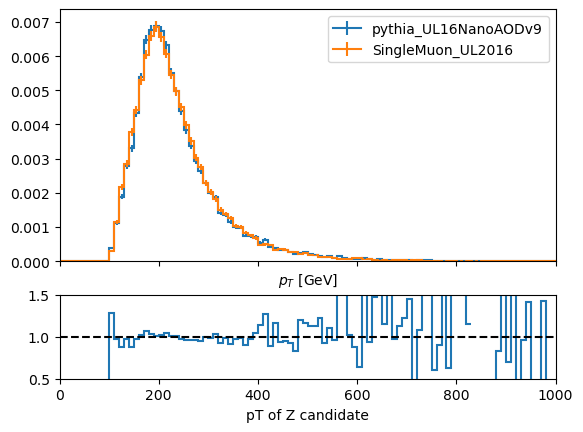

In [15]:
from coffea.hist import plot1d
import matplotlib.pyplot as plt
import mplhep as hep
import hist
fig, (ax, rax) = plt.subplots(
    2, 1,
    gridspec_kw={"height_ratios":[3,1]},
    sharex=True
)
plt.sca(ax)
out['pt_Z'].project('dataset', 'pt')[:, hist.rebin(1)].plot(density = True)

plt.legend()
#plt.yscale("log")
plt.sca(rax)
vals0 = out['pt_Z'].project('dataset', 'pt')[0, hist.rebin(1)].values()
vals1 = out['pt_Z'].project('dataset', 'pt')[1, hist.rebin(1)].values()
vals0 = vals0/vals0.sum()
vals1 = vals1/vals1.sum()
hep.histplot(vals0/vals1, out['pt_Z'][:, hist.rebin(1), :].axes[1].edges)
plt.ylim(0.5, 1.5)
plt.xlim(0,1000)
plt.hlines(1, 0, 1000, color= 'k', ls = '--')
plt.xlabel("pT of Z candidate")

/tmp/ipykernel_7897/1450473761.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_7897/1450473761.py:20: RuntimeWarning: divide by zero encountered in divide
  hep.histplot(vals0/vals1, out['pt_el0'][:, hist.rebin(1), :].axes[1].edges)
/tmp/ipykernel_7897/1450473761.py:20: RuntimeWarning: invalid value encountered in divide
  hep.histplot(vals0/vals1, out['pt_el0'][:, hist.rebin(1), :].axes[1].edges)


Text(0.5, 0, 'pT of positive electron')

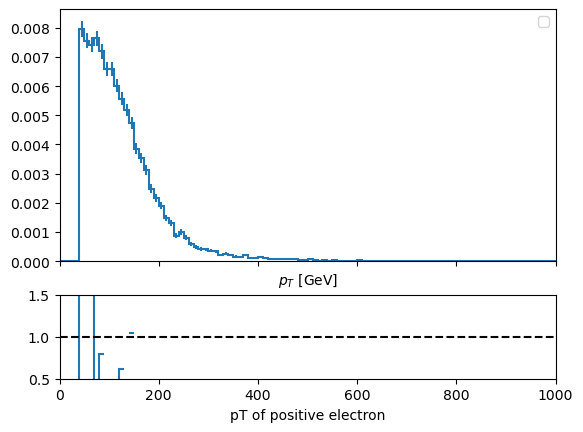

In [16]:
from coffea.hist import plot1d
import matplotlib.pyplot as plt
import mplhep as hep
import hist
fig, (ax, rax) = plt.subplots(
    2, 1,
    gridspec_kw={"height_ratios":[3,1]},
    sharex=True
)
plt.sca(ax)
out['pt_el0'].project('dataset', 'pt')[0, hist.rebin(1)].plot(density = True)

plt.legend()
#plt.yscale("log")
plt.sca(rax)
vals0 = out['pt_el0'].project('dataset', 'pt')[0, hist.rebin(1)].values()
vals1 = out['pt_el0'].project('dataset', 'pt')[1, hist.rebin(1)].values()
vals0 = vals0/vals0.sum()
vals1 = vals1/vals1.sum()
hep.histplot(vals0/vals1, out['pt_el0'][:, hist.rebin(1), :].axes[1].edges)
plt.ylim(0.5, 1.5)
plt.xlim(0,1000)
plt.hlines(1, 0, 1000, color= 'k', ls = '--')
plt.xlabel("pT of positive electron")

In [12]:
out['pt_Z'].project('dataset').values()

array([33660.74772345, 29639.        ])

In [13]:
out['cutflow']

defaultdict_accumulator(int,
                        {'pythia_UL16NanoAODv9_all': 82448537,
                         'SingleMuon_UL2016_all': 331976208})